In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')
rdir = '/home/kat/Repos/SALSA/results/'

In [96]:
import pandas as pd

runs = ['salsa','contra','ae','morgan']
run_dict = {'salsa':'SALSA', 'contra':'Contrast AE', 'ae':'Vanilla AE', 'morgan':'ECFP'}

df = pd.DataFrame()
for run in runs:
    f = '/home/kat/Repos/SALSA/mutual_infos/2022041804_04_12000n_extended_'
    _df = pd.read_csv(f'{f}{run}.csv')
    _df['Method'] = run_dict[run]
    df = pd.concat((df,_df))
    
props = ['MolWt','HeavyAtomCount','FractionCSP3', 'TPSA', 'NumHAcceptors', 
     'NumHDonors', 'NumRotatableBonds', 'MolLogP']

# usecols = ['Method','MolWt','HeavyAtomCount','FractionCSP3', 'TPSA', 
#            'NumRotatableBonds', 'MolLogP']
usecols = ['Method','HeavyAtomCount','FractionCSP3', 'TPSA', 
           'NumRotatableBonds', 'MolLogP']
df = df[usecols]
# df

In [97]:
import numpy as np
from matplotlib.patches import PathPatch
import seaborn as sns
import matplotlib.pyplot as plt

def adjust_box_widths(g, fac):
    """
    Adjust the widths of a seaborn-generated boxplot.
    """

    # iterating through Axes instances
    for ax in g.axes:

        # iterating through axes artists:
        for c in ax.get_children():

            # searching for PathPatches
            if isinstance(c, PathPatch):
                # getting current width of box:
                p = c.get_path()
                verts = p.vertices
                verts_sub = verts[:-1]
                xmin = np.min(verts_sub[:, 0])
                xmax = np.max(verts_sub[:, 0])
                xmid = 0.5*(xmin+xmax)
                xhalf = 0.5*(xmax - xmin)

                # setting new width of box
                xmin_new = xmid-fac*xhalf
                xmax_new = xmid+fac*xhalf
                verts_sub[verts_sub[:, 0] == xmin, 0] = xmin_new
                verts_sub[verts_sub[:, 0] == xmax, 0] = xmax_new

                # setting new width of median line
                for l in ax.lines:
                    if np.all(l.get_xdata() == [xmin, xmax]):
                        l.set_xdata([xmin_new, xmax_new])

In [98]:
df_melt = pd.melt(df, var_name='Property',value_name='Mutual info', id_vars=['Method'])

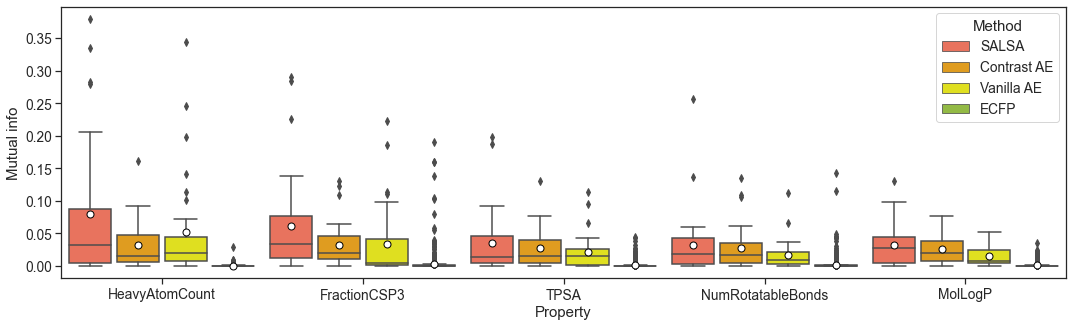

In [99]:
sns.set_theme(style='ticks',font_scale=1.25) #,palette='muted')

pal = ['tomato', 'orange', 'yellow','yellowgreen'] #  '#7D9EC0']

fig = plt.figure(figsize=(18,5))
ax = sns.boxplot(data=df_melt, x="Property", y="Mutual info", hue="Method", 
                 palette=pal, width=.95, showmeans=True,
                 meanprops={"marker":"o",
                            "markerfacecolor":"white", 
                            "markeredgecolor":"black",
                            "markersize":"7"})
adjust_box_widths(fig, 0.9)

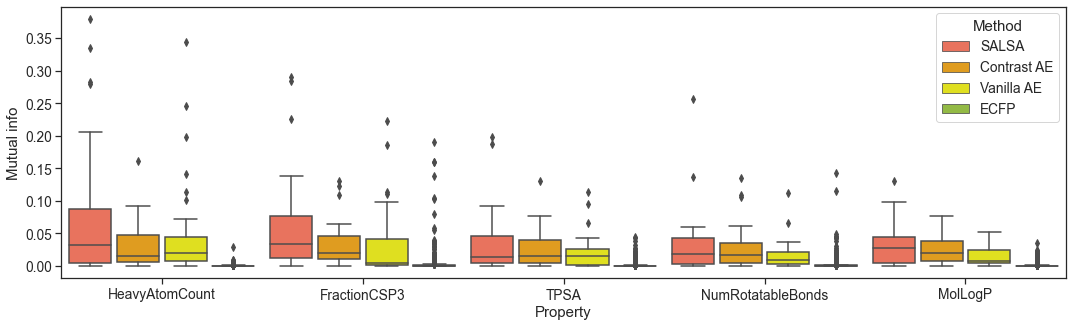

In [100]:
fig = plt.figure(figsize=(18,5))
ax = sns.boxplot(data=df_melt, x="Property", y="Mutual info", hue="Method", 
                 palette=pal, width=.95, showmeans=False,
                 meanprops={"marker":"o",
                            "markerfacecolor":"white", 
                            "markeredgecolor":"black",
                            "markersize":"7"})
adjust_box_widths(fig, 0.9)

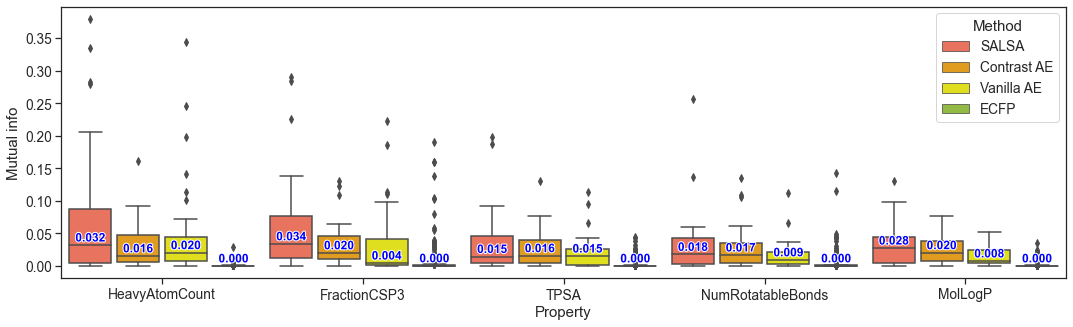

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

def add_median_labels(ax, precision='.3f'):
    lines = ax.get_lines()
    boxes = [c for c in ax.get_children() if type(c).__name__ == 'PathPatch']
    lines_per_box = int(len(lines) / len(boxes))
    for median in lines[4:len(lines):lines_per_box]:
        x, y = (data.mean() for data in median.get_data())
        # choose value depending on horizontal or vertical plot orientation
        value = x if (median.get_xdata()[1] - median.get_xdata()[0]) == 0 else y
        text = ax.text(x, y+0.01, f'{value:{precision}}', ha='center', va='center',
                       fontsize=12, fontweight='bold', color='blue')
        # create median-colored border around white text for contrast
        text.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='white'), # median.get_color()),
            path_effects.Normal(),
        ])
        
pal = ['tomato', 'orange', 'yellow','yellowgreen'] #  '#7D9EC0']
# pal = 'Set3'

fig, axes = plt.subplots(1, 1, figsize=(18, 5))
ax = sns.boxplot(data=df_melt, x="Property", y="Mutual info", hue="Method", 
                 palette=pal, width=.95, showfliers=True)
add_median_labels(ax)
adjust_box_widths(fig, 0.9)
plt.show()